In [1]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import matplotlib.pyplot as plt
import time

In [2]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="yolov8",
    model_path="yolov8n.pt",
    confidence_threshold=0.25,
    device="cpu"
)
print("Model loaded with SAHI ✓")

Model loaded with SAHI ✓


Performing prediction on 15 slices.
Persons detected WITH SAHI: 39


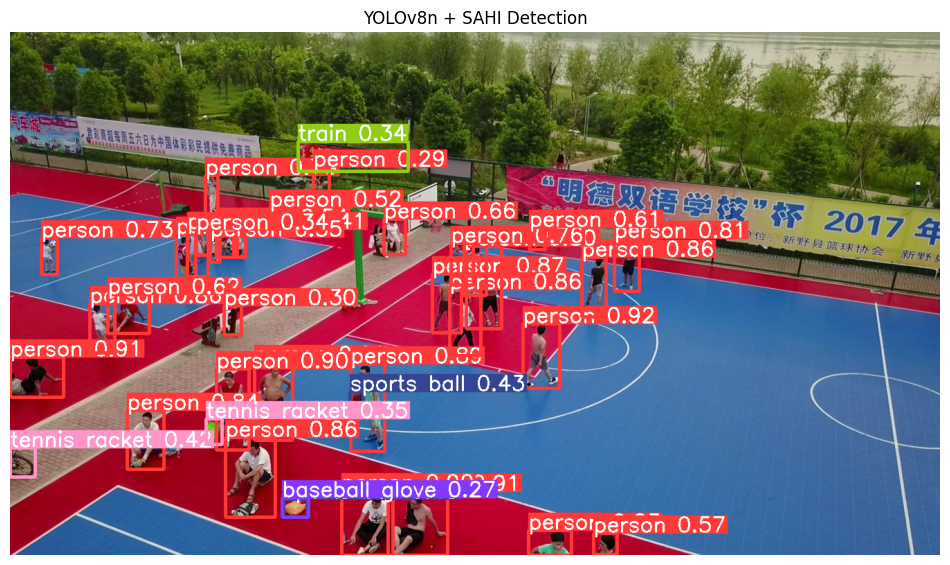

In [3]:
frame_path = "../data/VisDrone2019-MOT-val/sequences/uav0000086_00000_v/0000001.jpg"

result = get_sliced_prediction(
    frame_path,
    detection_model,
    slice_height=320,
    slice_width=320,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

print(f"Persons detected WITH SAHI: {len(result.object_prediction_list)}")

result.export_visuals(export_dir="../results/", file_name="detection_v2_sahi")
img = cv2.imread("../results/detection_v2_sahi.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,8))
plt.imshow(img_rgb)
plt.title("YOLOv8n + SAHI Detection")
plt.axis('off')
plt.show()

In [4]:
v1_count = 20   # your baseline result

v2_count = len(result.object_prediction_list)

print("=" * 40)
print("Comparison: Standard vs SAHI")
print("=" * 40)
print(f"Standard YOLOv8n:   {v1_count} persons detected")
print(f"YOLOv8n + SAHI:     {v2_count} persons detected")
print(f"Improvement:        +{v2_count - v1_count} detections")

Comparison: Standard vs SAHI
Standard YOLOv8n:   20 persons detected
YOLOv8n + SAHI:     39 persons detected
Improvement:        +19 detections


In [5]:
times = []
for i in range(3):
    t0 = time.time()
    result = get_sliced_prediction(
        frame_path,
        detection_model,
        slice_height=320,
        slice_width=320,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )
    t1 = time.time()
    times.append(t1 - t0)

avg_time = sum(times) / len(times)
fps_sahi = 1 / avg_time
print(f"SAHI FPS on CPU: {fps_sahi:.2f}")


Performing prediction on 15 slices.
Performing prediction on 15 slices.
Performing prediction on 15 slices.
SAHI FPS on CPU: 0.24


## Engineering Trade-off: Speed vs Accuracy

| Method | Persons Detected | FPS (CPU) |
|--------|-----------------|-----------|
| YOLOv8n standard | 20 | ~4.78 fps |
| YOLOv8n + SAHI | 39 | ~0.24 fps |

**Conclusion:** SAHI significantly improves small person detection
at the cost of lower FPS. For real-time on drone hardware, SAHI 
slice size can be increased (fewer tiles = faster) trading some
accuracy back for speed.

**On edge hardware (Jetson):** TensorRT export would recover
most of this FPS loss even with SAHI.